In [ ]:
#Data Analysis
#Contents-
#Data Acquisition
#Data Wrangling
#Exploratory Data Analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import requests
from io import StringIO

url="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_base.csv"
res=requests.get(url)
if res.status_code==200:
  df=pd.read_csv(StringIO(res.text),header=None)
else:
  print("Failed to retrieve data:",res.status_code)



In [ ]:
headers = ['Manufacturer', 'Category', 'Screen', 'GPU', 'OS', 'CPU_core', 'Screen_Size_inch', 'CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'Weight_kg', 'Price']
df.columns = headers
display(df.head())

,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,Acer,4,IPS Panel,2,1,5,35.56,1.6,8,256,1.6,978
1,Dell,3,Full HD,1,1,3,39.624,2.0,4,256,2.2,634
2,Dell,3,Full HD,1,1,7,39.624,2.7,8,256,2.2,946
3,Dell,4,IPS Panel,2,1,5,33.782,1.6,8,128,1.22,1244
4,HP,4,Full HD,2,1,7,39.624,1.8,8,256,1.91,837


In [ ]:
print(df.describe())

         Category         GPU          OS    CPU_core  CPU_frequency  \
count  238.000000  238.000000  238.000000  238.000000     238.000000   
mean     3.205882    2.151261    1.058824    5.630252       2.360084   
std      0.776533    0.638282    0.235790    1.241787       0.411393   
min      1.000000    1.000000    1.000000    3.000000       1.200000   
25%      3.000000    2.000000    1.000000    5.000000       2.000000   
50%      3.000000    2.000000    1.000000    5.000000       2.500000   
75%      4.000000    3.000000    1.000000    7.000000       2.700000   
max      5.000000    3.000000    2.000000    7.000000       2.900000   

           RAM_GB  Storage_GB_SSD        Price  
count  238.000000      238.000000   238.000000  
mean     7.882353      245.781513  1462.344538  
std      2.482603       34.765316   574.607699  
min      4.000000      128.000000   527.000000  
25%      8.000000      256.000000  1066.500000  
50%      8.000000      256.000000  1333.000000  
75%     

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Manufacturer      238 non-null    object 
 1   Category          238 non-null    int64  
 2   Screen            238 non-null    object 
 3   GPU               238 non-null    int64  
 4   OS                238 non-null    int64  
 5   CPU_core          238 non-null    int64  
 6   Screen_Size_inch  238 non-null    object 
 7   CPU_frequency     238 non-null    float64
 8   RAM_GB            238 non-null    int64  
 9   Storage_GB_SSD    238 non-null    int64  
 10  Weight_kg         238 non-null    object 
 11  Price             238 non-null    int64  
dtypes: float64(1), int64(7), object(4)
memory usage: 22.4+ KB
None


In [ ]:
df['Weight_kg'] = df['Weight_kg'].replace('?', np.nan)
df['Weight_kg'] = df['Weight_kg'].astype(float)
print(df['Weight_kg'].info())

df['Screen_Size_inch'] = df['Screen_Size_inch'].replace('?', np.nan)
df['Screen_Size_inch'] = df['Screen_Size_inch'].astype(float)
print(df['Screen_Size_inch'].info())


<class 'pandas.core.series.Series'>
RangeIndex: 238 entries, 0 to 237
Series name: Weight_kg
Non-Null Count  Dtype  
--------------  -----  
233 non-null    float64
dtypes: float64(1)
memory usage: 2.0 KB
None
<class 'pandas.core.series.Series'>
RangeIndex: 238 entries, 0 to 237
Series name: Screen_Size_inch
Non-Null Count  Dtype  
--------------  -----  
234 non-null    float64
dtypes: float64(1)
memory usage: 2.0 KB
None


In [ ]:
#-----------------------------------------------------------------------------------------------------------------------------------------
#                           DATA WRANGLING
#-----------------------------------------------------------------------------------------------------------------------------------------

filepath = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/auto.csv"
headers = ["symboling","normalized-losses","make","fuel-type","aspiration", "num-of-doors","body-style",
         "drive-wheels","engine-location","wheel-base", "length","width","height","curb-weight","engine-type",
         "num-of-cylinders", "engine-size","fuel-system","bore","stroke","compression-ratio","horsepower",
         "peak-rpm","city-mpg","highway-mpg","price"]
df1 = pd.read_csv(filepath, names=headers)
df1.head()


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [ ]:
df1.replace('?',np.nan,inplace=True) # Replacing the missing value with NaN
#Checking the missing values in both the dataframes.
missing_value1=df1.isnull()
missing_value=df.isnull()
for column in missing_value1.columns.values.tolist():
  print(column)
  print(missing_value1[column].value_counts())
  print("________")

symboling
symboling
False    205
Name: count, dtype: int64
________
normalized-losses
normalized-losses
False    164
True      41
Name: count, dtype: int64
________
make
make
False    205
Name: count, dtype: int64
________
fuel-type
fuel-type
False    205
Name: count, dtype: int64
________
aspiration
aspiration
False    205
Name: count, dtype: int64
________
num-of-doors
num-of-doors
False    203
True       2
Name: count, dtype: int64
________
body-style
body-style
False    205
Name: count, dtype: int64
________
drive-wheels
drive-wheels
False    205
Name: count, dtype: int64
________
engine-location
engine-location
False    205
Name: count, dtype: int64
________
wheel-base
wheel-base
False    205
Name: count, dtype: int64
________
length
length
False    205
Name: count, dtype: int64
________
width
width
False    205
Name: count, dtype: int64
________
height
height
False    205
Name: count, dtype: int64
________
curb-weight
curb-weight
False    205
Name: count, dtype: int64
________
en

In [ ]:
#To collectively check for the number of missing values.
for column in missing_value.columns.values.tolist():
  print(column)
  print(missing_value[column].value_counts())
  print("____")



Manufacturer
Manufacturer
False    238
Name: count, dtype: int64
____
Category
Category
False    238
Name: count, dtype: int64
____
Screen
Screen
False    238
Name: count, dtype: int64
____
GPU
GPU
False    238
Name: count, dtype: int64
____
OS
OS
False    238
Name: count, dtype: int64
____
CPU_core
CPU_core
False    238
Name: count, dtype: int64
____
Screen_Size_inch
Screen_Size_inch
False    234
True       4
Name: count, dtype: int64
____
CPU_frequency
CPU_frequency
False    238
Name: count, dtype: int64
____
RAM_GB
RAM_GB
False    238
Name: count, dtype: int64
____
Storage_GB_SSD
Storage_GB_SSD
False    238
Name: count, dtype: int64
____
Weight_kg
Weight_kg
False    233
True       5
Name: count, dtype: int64
____
Price
Price
False    238
Name: count, dtype: int64
____


In [ ]:
#It is observed that only Weight_kg has 5 missing values from df
  #From df1- normalized_losses-21 missing values,
            #bore-4 missing values
            #stroke-4 missing values
            #horsepower-2 missing values
            #price-4 missing values
            #peak-rpm-2 missing values
#Replacing / dropping the missing value..


## Replace by mean:

"normalized-losses": 41 missing data, replace them with mean

"stroke": 4 missing data, replace them with mean

"bore": 4 missing data, replace them with mean

"horsepower": 2 missing data, replace them with mean

"peak-rpm": 2 missing data, replace them with mean

## Replace by frequency:

"num-of-doors": 2 missing data, replace them with "four"

__Reason: 84% sedans are four doors. Since four doors is most frequent, it is most likely to occur__

## Drop the whole row:

"price": 4 missing data, simply delete the whole row

__Reason: You want to predict price. You cannot use any data entry without price data for prediction; therefore any row now without price data is not useful to you.__

In [ ]:
avg_weight_kg=df['Weight_kg'].astype(float).mean(axis=0)
avg_norm_loss=df1['normalized-losses'].astype(float).mean(axis=0)
avg_bore=df1['bore'].astype(float).mean(axis=0)
avg_stroke=df1['stroke'].astype(float).mean(axis=0)
avg_horsepower=df1['horsepower'].astype(float).mean(axis=0)
avg_peak_rpm=df1['peak-rpm'].astype(float).mean(axis=0)

#Replacing the missing_value with the average value..
df['Weight_kg'].replace(np.nan,avg_weight_kg,inplace=True)
df1['normalized-losses'].replace(np.nan,avg_norm_loss,inplace=True)
df1['bore'].replace(np.nan,avg_bore,inplace=True)
df1['stroke'].replace(np.nan,avg_stroke,inplace=True)
df1['horsepower'].replace(np.nan,avg_horsepower,inplace=True)
df1['peak-rpm'].replace(np.nan,avg_peak_rpm,inplace=True)


/tmp/ipykernel_7583/2468044837.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Weight_kg'].replace(np.nan,avg_weight_kg,inplace=True)
/tmp/ipykernel_7583/2468044837.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=T

In [ ]:
#Since num-of-doors is a categorical variable, we cannot use mean() to replace the missing values, thereby need to use frequency.
print(df1['num-of-doors'].value_counts())
print("The frequent number of doors are:",df1['num-of-doors'].value_counts().idxmax())
#It says that maximum number if doors are four, therefore replace the missing value with 4
df1['num-of-doors'].replace(np.nan,"four",inplace=True)

# simply drop whole row with NaN in "price" column
df1.dropna(subset=['price'],axis=0,inplace=True)

#Reset index, since dropped two rows
df1.reset_index(drop=True,inplace=True)

num-of-doors
four    114
two      89
Name: count, dtype: int64
The frequent number of doors are: four


/tmp/ipykernel_7583/2674309311.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['num-of-doors'].replace(np.nan,"four",inplace=True)


In [ ]:
df1.shape

(201, 26)

In [ ]:
#Formatting the datatype
df1[["bore", "stroke"]] = df1[["bore", "stroke"]].astype("float")
df1[["normalized-losses"]] = df1[["normalized-losses"]].astype("int")
df1[["price"]] = df1[["price"]].astype("float")
df1[["peak-rpm"]] = df1[["peak-rpm"]].astype("float")
df1[['horsepower']]=df1[['horsepower']].astype('int',copy=True)
df1.dtypes

,0
symboling,int64
normalized-losses,int64
make,object
fuel-type,object
aspiration,object
num-of-doors,object
body-style,object
drive-wheels,object
engine-location,object
wheel-base,float64


In [ ]:
#Data Standardization

#transforming mpg to L/100km
df1['highway-mpg']=235/df1['highway-mpg']
df1.rename(columns={'highway-mpg':'highway-L/100km'},inplace=True)

#normalisation using simple feature scaling..
# scaling length so that variable average is 0, variance is 1, and variable value lies between 0 and 1.
df1['length']=df1['length']/df1['length'].max()

#scaling width using min-max
df1['width']=(df1['width']-df1['width'].min())/(df1['width'].max()-df1['width'].min())

#scaling height using z-score
df1['height']=(df1['height']-df1['height'].mean())/df1['height'].std()
df1[['length','width','height']]



,length,width,height
0,0.811148,0.324786,-2.029015
1,0.811148,0.324786,-2.029015
2,0.822681,0.444444,-0.558319
3,0.848630,0.504274,0.217881
4,0.848630,0.521368,0.217881
...,...,...,...
196,0.907256,0.735043,0.708112
197,0.907256,0.726496,0.708112
198,0.907256,0.735043,0.708112
199,0.907256,0.735043,0.708112


In [ ]:
#Binning the data in python

bins=np.linspace(min(df1['horsepower']),max(df1['horsepower']),4)
print(bins)
group=['Low','Medium','High']
df1['horsepower-categorisation']=pd.cut(df1['horsepower'],bins,labels=group,include_lowest=True)
print(df1[['horsepower','horsepower-categorisation']].head())
print(df1['horsepower-categorisation'].value_counts())


[ 48.         119.33333333 190.66666667 262.        ]
   horsepower horsepower-categorisation
0         111                       Low
1         111                       Low
2         154                    Medium
3         102                       Low
4         115                       Low
horsepower-categorisation
Low       153
Medium     43
High        5
Name: count, dtype: int64


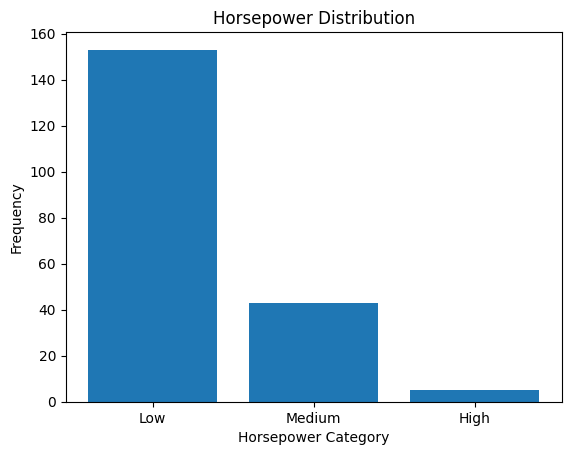

In [ ]:
#Plotting the horsepower distribution into histogram
counts = df1['horsepower-categorisation'].value_counts()
plt.bar(counts.index, counts.values)
plt.xlabel("Horsepower Category")
plt.ylabel("Frequency")
plt.title("Horsepower Distribution")
plt.show()

In [ ]:
#Get dummies to assign numerical values to categorical variable
d1=pd.get_dummies(df1['fuel-type'])
print(d1.head())

#concat() to df1
df1=pd.concat([df1,d1],axis=1)
print(df1.head())

   diesel   gas
0   False  True
1   False  True
2   False  True
3   False  True
4   False  True
   symboling  normalized-losses         make fuel-type aspiration  \
0          3                122  alfa-romero       gas        std   
1          3                122  alfa-romero       gas        std   
2          1                122  alfa-romero       gas        std   
3          2                164         audi       gas        std   
4          2                164         audi       gas        std   

  num-of-doors   body-style drive-wheels engine-location  wheel-base  ...  \
0          two  convertible          rwd           front        88.6  ...   
1          two  convertible          rwd           front        88.6  ...   
2          two    hatchback          rwd           front        94.5  ...   
3         four        sedan          fwd           front        99.8  ...   
4         four        sedan          4wd           front        99.4  ...   

   stroke  compression-rat

In [ ]:
# Get dummies to assign numerical values to the 'aspiration' categorical variable
d2 = pd.get_dummies(df1['aspiration'])
print(d2.head())

# Concatenate the new indicator variables with df1
df1 = pd.concat([df1, d2], axis=1)
print(df1.head())

#df1.drop('aspiration',axis=1,inplace=True)--> use this line to drop the aspiration column

    std  turbo
0  True  False
1  True  False
2  True  False
3  True  False
4  True  False
   symboling  normalized-losses         make fuel-type aspiration  \
0          3                122  alfa-romero       gas        std   
1          3                122  alfa-romero       gas        std   
2          1                122  alfa-romero       gas        std   
3          2                164         audi       gas        std   
4          2                164         audi       gas        std   

  num-of-doors   body-style drive-wheels engine-location  wheel-base  ...  \
0          two  convertible          rwd           front        88.6  ...   
1          two  convertible          rwd           front        88.6  ...   
2          two    hatchback          rwd           front        94.5  ...   
3         four        sedan          fwd           front        99.8  ...   
4         four        sedan          4wd           front        99.4  ...   

   horsepower  peak-rpm  city-mp

In [ ]:
#Save this preprocessed file

df1.to_csv("cleaned_car_data.csv")

In [ ]:
#_______________________________________________________________
#                            EXPLORATORY
#                              DATA
#                             ANALYSIS
#_______________________________________________________________

import pandas as pd
from scipy.stats import chi2_contingency

# Example: Create a contingency table for 'Manufacturer' and 'Category'
# You should choose the categorical columns relevant to your analysis.
contingency_table = pd.crosstab(df['Manufacturer'], df['Category'])

# Perform the Chi-Square Test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Display results
print("Contingency Table:\n", contingency_table)
print("\nChi-square Statistic:", chi2)
print("Degrees of Freedom:", dof)
print("P-value:", p)
print("Expected Frequencies:\n", expected)

Contingency Table:
 Category      1  2   3   4  5
Manufacturer                 
Acer          2  0  13   4  0
Asus          2  0  10   6  0
Dell          3  0  41  22  5
HP            0  1  35   9  4
Huawei        0  0   0   1  0
Lenovo        2  0  39  11  0
MSI           4  0   0   0  0
Razer         1  0   0   0  0
Samsung       0  0   0   5  0
Toshiba       0  0  16   1  0
Xiaomi        0  0   0   1  0

Chi-square Statistic: 128.7603408020198
Degrees of Freedom: 40
P-value: 2.946894720189204e-11
Expected Frequencies:
 [[1.11764706e+00 7.98319328e-02 1.22941176e+01 4.78991597e+00
  7.18487395e-01]
 [1.05882353e+00 7.56302521e-02 1.16470588e+01 4.53781513e+00
  6.80672269e-01]
 [4.17647059e+00 2.98319328e-01 4.59411765e+01 1.78991597e+01
  2.68487395e+00]
 [2.88235294e+00 2.05882353e-01 3.17058824e+01 1.23529412e+01
  1.85294118e+00]
 [5.88235294e-02 4.20168067e-03 6.47058824e-01 2.52100840e-01
  3.78151261e-02]
 [3.05882353e+00 2.18487395e-01 3.36470588e+01 1.31092437e+01
  1.966386

result of a Chi-square test performed to assess the association between 'Manufacturer' and 'Category' in your df DataFrame.

Contingency Table: This table displays the observed counts for each combination of 'Manufacturer' and 'Category'. For example, Acer has 2 laptops in Category 1 and 13 in Category 3.
Chi-square Statistic (128.76): This value quantifies how much the observed frequencies deviate from what would be expected if there were no relationship between laptop manufacturer
 and category. A larger value suggests a greater deviation.
Degrees of Freedom (40): This relates to the number of independent pieces of information used to calculate the statistic.
P-value (2.946894720189204e-11): This is a very small number. Since the p-value (2.95e-11) is significantly less than the common significance level of 0.05, we reject the null
 hypothesis of independence. This means there is a statistically significant association between the manufacturer of a laptop and its category.
Expected Frequencies: This table shows the cell counts that would be expected if 'Manufacturer' and 'Category' were completely independent. Comparing these to the observed counts in
the Contingency Table helps you see where the observed values are higher or lower than expected, indicating the nature of the association.

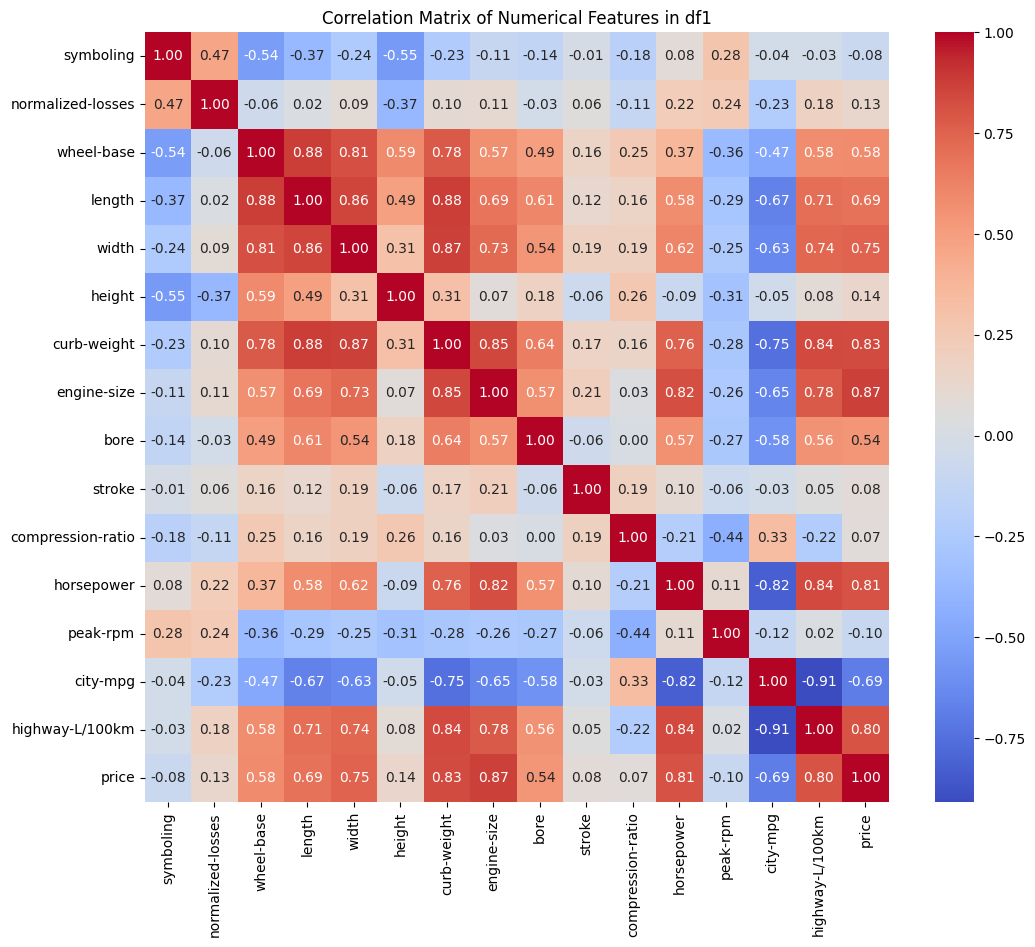

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

plt.figure(figsize=(12, 10)) # Increase figure size
df_relation=df1.select_dtypes(include=['float64','int64']).corr()
sns.heatmap(df_relation, annot=True, fmt=".2f", cmap="coolwarm", annot_kws={"size": 10}) # Add font size and format
plt.title('Correlation Matrix of Numerical Features in df1') # Add a title
plt.show()

#Red shows that the variables are highly/positively relational.
#Blue shows that the variables are negatively relational.
#White and near to white shows that, there is merely/ week relationship between the variables
#The relation from a variable to itself is alaways +1, as it is highly relational to itself(dark red)


(0.0, 53167.926646640306)

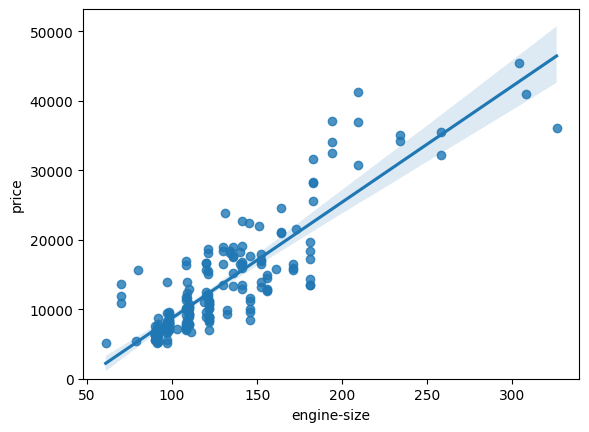

In [ ]:
#Positive relation
sns.regplot(x='engine-size',y='price',data=df1)
plt.ylim(0,)

(0.0, 47714.85469604583)

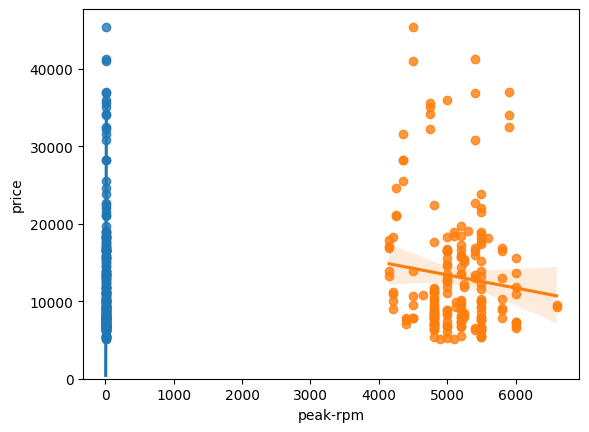

In [ ]:
#Weak corelation or no significant corelation
sns.regplot(x='highway-L/100km',y='price',data=df1)
plt.ylim(0,)
sns.regplot(x='peak-rpm',y='price',data=df1)
plt.ylim(0,)

(0.0, 276.5841259014362)

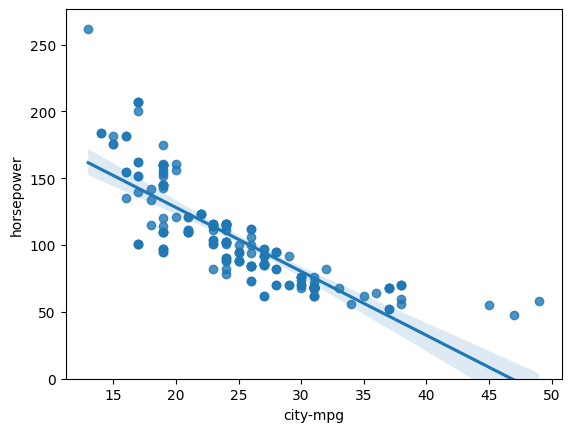

In [ ]:
#Negative relation -reference from the heatmap
sns.regplot(x='city-mpg',y='horsepower',data=df1)
plt.ylim(0,)

<Axes: xlabel='engine-location', ylabel='price'>

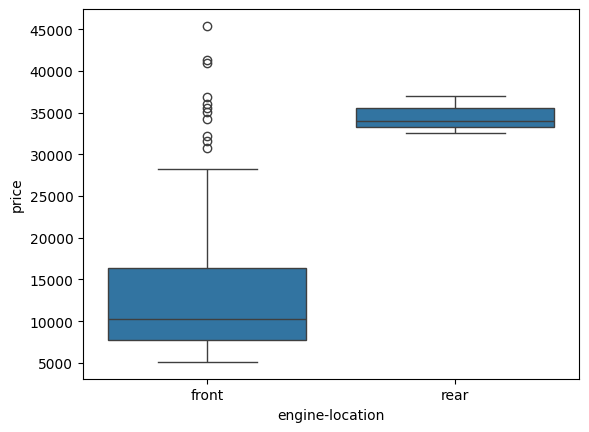

In [ ]:
#Use of boxplot for categorical variable

sns.boxplot(x='engine-location',y='price',data=df1)

# The boxplot shows that the distribution of price is much wider when engine-location is 'front'and the median
    #price is lower compared to when the engine-locator is 'rear.
# front engine locaiton => there might be several outliers indicating unsually high prices for this category.
# Since there appears to be 'only one data point' for this category, this single
# data point itself could be considered an outlier if its price is significantly
# higher or lower than the general price range of the 'front' engine-location
# vehicles, and if it lies far beyond the calculated whiskers of the overall
# dataset's price distribution. Without seeing the plot, it's hard to tell
# precisely, but its uniqueness and higher price suggest it's an exceptional
# case.


  drive-wheels         price
0          4wd  10241.000000
1          fwd   9244.779661
2          rwd  19757.613333
              count
drive-wheels       
fwd             118
rwd              75
4wd               8


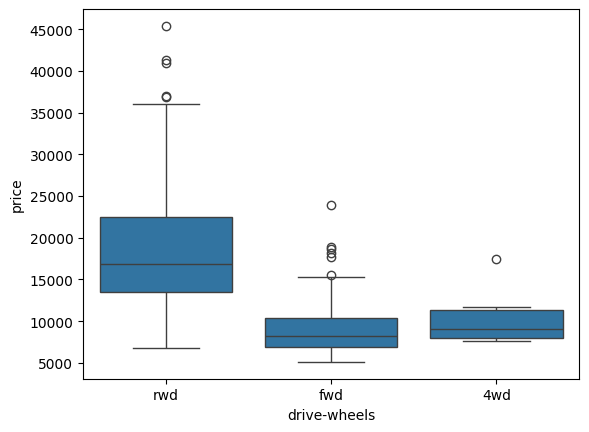

In [ ]:
#Group by to find the average price of each type of drive-wheels
group_by_include=df1[['drive-wheels','price']]
df_grouped=group_by_include.groupby(['drive-wheels'], as_index=False).agg({'price':'mean'})
print(df_grouped)

sns.boxplot(x='drive-wheels',y='price',data=df1)
print(df1['drive-wheels'].value_counts().to_frame())


In [ ]:
#From group by , we can draw the following insights......
         # Cars with rear wheel drive have highest average price,
         # Front wheel drive cars tend to have lowest price.
         # This suggests that 'rsw' might be associated with  higher-end, uxury or performance vehicles,
         # while 'fwd' is prevalent in more economical or mass-marekt cars.
         #4wd fall in the middle, reflecting a balance between utility and cost.
# There can be many reasons for less outliers in 4wd cars.
        # Homogenous market segment: might belong to more specialized or niche market where price variation is naturally lower.
        # Smaller sample size:in the value_counts() 4wd frequency is only 8, thereby small chance of encountering outliers.
        # Consistent features and pricing..



                   price                                            \
body-style   convertible       hardtop     hatchback         sedan   
drive-wheels                                                         
4wd                  0.0      0.000000   7603.000000  12647.333333   
fwd              11595.0   8249.000000   8396.387755   9811.800000   
rwd              23949.6  24202.714286  14337.777778  21711.833333   

                            
body-style           wagon  
drive-wheels                
4wd            9095.750000  
fwd            9997.333333  
rwd           16994.222222  


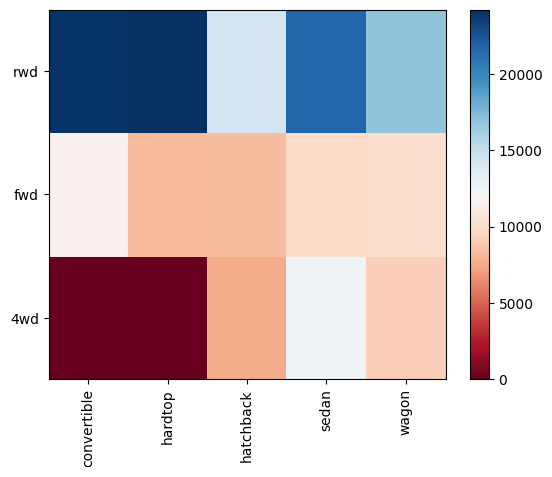

In [ ]:
#PIVOT TABLE
grouped_test1=df1[['drive-wheels','body-style','price']].groupby(['drive-wheels','body-style'],as_index=False).mean()
grouped_pivot = grouped_test1.pivot(index='drive-wheels',columns='body-style')
grouped_pivot=grouped_pivot.fillna(0)
print(grouped_pivot)

#use the grouped results
fig, ax = plt.subplots()
im = ax.pcolor(grouped_pivot, cmap='RdBu')

#label names
row_labels = grouped_pivot.columns.levels[1]
col_labels = grouped_pivot.index

#move ticks and labels to the center
ax.set_xticks(np.arange(grouped_pivot.shape[1]) + 0.5, minor=False)
ax.set_yticks(np.arange(grouped_pivot.shape[0]) + 0.5, minor=False)

#insert labels
ax.set_xticklabels(row_labels, minor=False)
ax.set_yticklabels(col_labels, minor=False)

#rotate label if too long
plt.xticks(rotation=90)

fig.colorbar(im)
plt.show()

In [ ]:
# The pivot table says that the rwd hardtop has much higher price .
# "0" indicates that there is no such car that is both 4wd and convertible or fwd and hardtop...
# In the heatmap, the area with dark red colors shows high-priced combinations
# while the dark blue area shows the low-priced combinations
#White area corresponds to no daataset with that particular combination (0 value)/


In [ ]:
from scipy import stats
#Using pearson corelation
df1.select_dtypes(include=['number']).corr()

#Wheel base vs price
pearson_coef,p_value=stats.pearsonr(df1['wheel-base'],df1['price'])
print("Wheel-base vs price")
print("Pearson corelation coeff is:",pearson_coef,"With a p-value:",p_value,"\n")

#Horsepower vs price
pearson_coef,p_value=stats.pearsonr(df1['horsepower'],df1['price'])
print("Horsepower vs price")
print("Pearson corelation coeff is:",pearson_coef,"With a p-value:",p_value,"\n")

#Length vs price
pearson_coef,p_value=stats.pearsonr(df1['length'],df1['price'])
print("length vs price")
print("Pearson corelation coeff is:",pearson_coef,"With a p-value:",p_value,"\n")

#Width vs price
pearson_coeff,p_value=stats.pearsonr(df1['width'],df1['price'])
print("width vs price")
print("Pearson corelation coeff is:",pearson_coeff,"With a p-value:",p_value,"\n")

#curb weight vs price
pearson_coeff,p_value=stats.pearsonr(df1['curb-weight'],df1['price'])
print("curb-weight vs price")
print("Pearson corelation coeff is:",pearson_coeff,"With a p-value:",p_value,"\n")

#Engine size vs price
pearson_coeff,p_value=stats.pearsonr(df1['engine-size'],df1['price'])
print("engine-size vs price")
print("Pearson corelation coeff is:",pearson_coeff,"With a p-value:",p_value,"\n")

#Bore vs price
pearson_coeff,p_value=stats.pearsonr(df1['bore'],df1['price'])
print("bore vs price")
print("Pearson corelation coeff is:",pearson_coeff,"With a p-value:",p_value,"\n")

#Bore vs price
pearson_coeff,p_value=stats.pearsonr(df1['bore'],df1['price'])
print("bore vs price")
print("Pearson corelation coeff is:",pearson_coeff,"With a p-value:",p_value,"\n")

#Highway-l/100km vs price
pearson_coeff,p_value=stats.pearsonr(df1['highway-L/100km'],df1['price'])
print("highway-L/100km vs price")
print("Pearson corelation coeff is:",pearson_coeff,"With a p-value:",p_value,"\n")

Wheel-base vs price
Pearson corelation coeff is: 0.584641822265508 With a p-value: 8.076488270732947e-20 

Horsepower vs price
Pearson corelation coeff is: 0.8096068016571054 With a p-value: 6.27353627065033e-48 

length vs price
Pearson corelation coeff is: 0.6906283804483639 With a p-value: 8.016477466159241e-30 

width vs price
Pearson corelation coeff is: 0.7512653440522674 With a p-value: 9.20033551048134e-38 

curb-weight vs price
Pearson corelation coeff is: 0.8344145257702844 With a p-value: 2.1895772388939584e-53 

engine-size vs price
Pearson corelation coeff is: 0.8723351674455184 With a p-value: 9.265491622198827e-64 

bore vs price
Pearson corelation coeff is: 0.5431553832626603 With a p-value: 8.049189483935246e-17 

bore vs price
Pearson corelation coeff is: 0.5431553832626603 With a p-value: 8.049189483935246e-17 

highway-L/100km vs price
Pearson corelation coeff is: 0.8011176263981975 With a p-value: 3.046784581041397e-46 



In [2]:
#Since the p-value is less than 0.001 for each case, we infer that all the variables are highly significant in relation with the price.
#pearson coeff for all is deviating towards 1 and thereby positively related to price..
